In [1]:
!pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hub pillow nltk

In [2]:
!pip install gensim -U


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")
from huggingface_hub import login

login("")

Gensim version: 4.4.0
Setup complete!


In [12]:
!pip install datasets

## Part A: Load Dataset (Same as Part 1)

In [13]:
from datasets import load_dataset
# Load dataset from Hugging Face
dataset = load_dataset("SetFit/20_newsgroups")
df = pd.DataFrame(dataset['train'])

# Use the SAME 3 categories you chose in Part 1
my_categories = ["rec.sport.hockey", "sci.space", "comp.graphics"]  # replace if needed

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

# Preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return tokens

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(lambda x: ' '.join(x))

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Selected categories: ['rec.sport.hockey', 'sci.space', 'comp.graphics']
Filtered dataset size: 1777
Sample tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


## Part A: Word2Vec - Training Your Own Embeddings


In [14]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1777 documents
Total tokens: 171167

Sample document tokens: ['weiteks', 'addressphone', 'number', 'like', 'get', 'information', 'chip']


In [15]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5053


In [16]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5053


## A.2 Exploring Word Embeddings

In [18]:
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [ 0.03829746  0.51563704  0.03360302 -0.08185337  0.09125827 -0.85875696
  0.5081405   0.91311157 -0.53906196 -1.0307565 ]


In [20]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  application: 0.9905
  user: 0.9818
  visualization: 0.9780
  environment: 0.9773
  virtual: 0.9755
  tool: 0.9704
  analysis: 0.9692
  database: 0.9670
  processing: 0.9659
  various: 0.9639

Words most similar to 'computer' (Skip-gram):
  exponent: 0.8060
  graphic: 0.7489
  graeme: 0.7415
  radiosity: 0.7388
  gem: 0.7349
  acm: 0.7293
  programmer: 0.7198
  raytracing: 0.7192
  molecular: 0.7149
  silicon: 0.7140


# Exercise A.1: Compare CBOW vs Skip-gram

In [21]:
my_test_words = ["hockey", "goal", "nasa", "space", "graphics"]

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'hockey':
  CBOW:     ['nhl', 'league', 'team', 'player', 'canadian']
  Skip-gram: ['league', 'canadian', 'ncaa', 'attended', 'basketball']

'goal':
  CBOW:     ['flyer', 'puck', 'scored', 'shot', 'left']
  Skip-gram: ['scored', 'powerplay', 'aslin', 'killing', 'swede']

'nasa':
  CBOW:     ['space', 'technology', 'science', 'shuttle', 'research']
  Skip-gram: ['dryden', 'ames', 'shafer', 'jsc', 'mary']

'space':
  CBOW:     ['nasa', 'station', 'shuttle', 'technology', 'national']
  Skip-gram: ['nasajscgm', 'administration', 'nasp', 'aerospace', 'jenks']
'graphics' not found in vocabulary!


**Similar results** for: hockey, goal, and space.

**Different results** for: nasa, and partly goal and space.

**Better model** for my domain: CBOW is better for general semantic relationships, while Skip-gram is better for specialized and rare words.

**Example 1**: For “nasa”, CBOW returned general scientific words like “space”, “technology”, and “research”, while Skip-gram returned more specific terms such as “dryden” and “ames”, which are closely related to NASA.

**Example 2**: For “goal”, CBOW returned clear hockey-related words like “puck”, “scored”, and “shot”, while Skip-gram returned more specific contextual words such as “powerplay”.

**Explanation of differences**: CBOW works better for frequent words and captures general meaning, while Skip-gram is more effective for rare and domain-specific words because it learns more detailed contextual relationships.

**The word “graphics”** was not found in the vocabulary, probably because it appeared fewer than 5 times in the filtered corpus or was removed during preprocessing.

# A.3 Word Analogies

In [24]:
# Analogy function (already good)
def find_analogy(model, word1, word2, word3):
    """
    word1 is to word2 as word3 is to ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"


print(" Analogy tests:\n")

# Example 1 (sports)
print("hockey : puck :: goal : ?")
print(find_analogy(model_skipgram, "hockey", "puck", "goal"))

# Example 2 (space domain)
print("\nnasa : space :: hockey : ?")
print(find_analogy(model_skipgram, "nasa", "space", "hockey"))

# Example 3 (action relation)
print("\ngoal : scored :: puck : ?")
print(find_analogy(model_skipgram, "goal", "scored", "puck"))

# Example 4 (organization relation)
print("\nnasa : research :: hockey : ?")
print(find_analogy(model_skipgram, "nasa", "research", "hockey"))

 Analogy tests:

hockey : puck :: goal : ?
[('slot', 0.7706875205039978), ('rebound', 0.7453174591064453), ('passed', 0.7134702801704407), ('pas', 0.7086631059646606), ('corner', 0.7065026760101318)]

nasa : space :: hockey : ?
[('league', 0.5550622940063477), ('canadian', 0.538824737071991), ('sport', 0.5250963568687439), ('basketball', 0.5197016596794128), ('college', 0.5025589466094971)]

goal : scored :: puck : ?
[('leg', 0.8703623414039612), ('faceoff', 0.8646716475486755), ('slid', 0.8626707792282104), ('glove', 0.8622421622276306), ('corner', 0.8544287085533142)]

nasa : research :: hockey : ?
[('college', 0.6048485040664673), ('east', 0.587748646736145), ('north', 0.5480695962905884), ('professional', 0.5455423593521118), ('association', 0.5447077751159668)]


## Exercise A.2: Create Domain-Specific Analogies



In [25]:
# -------------------------
# Analogy 1 (sports domain)
# hockey is to puck as goal is to ?
# -------------------------
analogy1 = find_analogy(model_skipgram, "hockey", "puck", "goal")
print("Analogy 1 (hockey : puck :: goal : ?)")
print(analogy1)


# -------------------------
# Analogy 2 (space vs sports)
# nasa is to space as hockey is to ?
# -------------------------
analogy2 = find_analogy(model_skipgram, "nasa", "space", "hockey")
print("\nAnalogy 2 (nasa : space :: hockey : ?)")
print(analogy2)

Analogy 1 (hockey : puck :: goal : ?)
[('slot', 0.7706875205039978), ('rebound', 0.7453174591064453), ('passed', 0.7134702801704407), ('pas', 0.7086631059646606), ('corner', 0.7065026760101318)]

Analogy 2 (nasa : space :: hockey : ?)
[('league', 0.5550622940063477), ('canadian', 0.538824737071991), ('sport', 0.5250963568687439), ('basketball', 0.5197016596794128), ('college', 0.5025589466094971)]


Yes, my analogies worked reasonably well. The results are not perfect, but they are meaningful and relevant to the domains in my dataset.

For the first analogy, “hockey” is to “puck” as “goal” is to ?, the model returned words such as “slot”, “rebound”, “passed”, and “corner”. These terms are related to hockey gameplay and scoring situations, so the result makes sense. It shows that the model captured contextual relationships between words used in the sports domain.

For the second analogy, “nasa” is to “space” as “hockey” is to ?, the model returned “league”, “canadian”, “sport”, “basketball”, and “college”. These words are clearly related to the sports domain, especially hockey, so this analogy also makes sense. It suggests that the model understood that NASA belongs to the space domain in the same way that hockey belongs to the sports domain.

Overall, the analogies worked, but only approximately. This is expected because the model was trained on a relatively small custom corpus. Word2Vec analogies usually perform better with much larger datasets and pretrained embeddings. Even so, the results show that the model learned useful semantic and domain-specific relationships.

# Part B: Pre-trained GloVe Embeddings


In [26]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [28]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  exponent: 0.8060
  graphic: 0.7489
  graeme: 0.7415
  radiosity: 0.7388
  gem: 0.7349
  acm: 0.7293
  programmer: 0.7198
  raytracing: 0.7192
  molecular: 0.7149
  silicon: 0.7140

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


**Exercise B.1: Compare Your Model vs GloVe**



In [29]:
# Choose 3 domain-specific words (safe choices from your vocab)
comparison_words = ["hockey", "goal", "nasa"]

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model (Skip-gram)
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe model
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'hockey'
Your Word2Vec:
  league: 0.752
  canadian: 0.744
  ncaa: 0.724
  attended: 0.722
  basketball: 0.720
GloVe:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731

Word: 'goal'
Your Word2Vec:
  scored: 0.800
  powerplay: 0.763
  aslin: 0.759
  killing: 0.758
  swede: 0.750
GloVe:
  goals: 0.871
  scored: 0.799
  scoring: 0.789
  minute: 0.772
  kick: 0.741

Word: 'nasa'
Your Word2Vec:
  dryden: 0.792
  ames: 0.787
  shafer: 0.776
  jsc: 0.746
  mary: 0.746
GloVe:
  shuttle: 0.778
  astronauts: 0.764
  spacecraft: 0.709
  space: 0.704
  endeavour: 0.692



My model is better for: nasa and goal.
Reason: It captures more domain-specific and detailed terms (e.g., “dryden”, “ames”, “powerplay”) that come directly from the dataset context.

GloVe is better for: hockey and general meanings of goal.
Reason: It provides cleaner and more general semantic words (e.g., “football”, “basketball”, “scoring”) because it is trained on a large corpus.

When to use each:
Custom model: when working with specific domain data where precise context matters.

Pre-trained model: when needing general understanding with limited data.

**B.2 GloVe Analogies**

In [30]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [31]:
# -------------------------
# Analogy 1 (sports domain)
# hockey is to puck as soccer is to ?
# -------------------------
result1 = glove_model.most_similar(
    positive=['puck', 'soccer'],
    negative=['hockey'],
    topn=3
)
print("\nAnalogy 1 (hockey : puck :: soccer : ?)")
print(result1)


# -------------------------
# Analogy 2 (space domain)
# nasa is to usa as esa is to ?
# -------------------------
result2 = glove_model.most_similar(
    positive=['usa', 'esa'],
    negative=['nasa'],
    topn=3
)
print("\nAnalogy 2 (nasa : usa :: esa : ?)")
print(result2)


# -------------------------
# Analogy 3 (general semantic)
# man is to king as woman is to ?
# -------------------------
result3 = glove_model.most_similar(
    positive=['king', 'woman'],
    negative=['man'],
    topn=3
)
print("\nAnalogy 3 (man : king :: woman : ?)")
print(result3)


Analogy 1 (hockey : puck :: soccer : ?)
[('ball', 0.6935651302337646), ('kick', 0.6672794222831726), ('deflected', 0.6646664142608643)]

Analogy 2 (nasa : usa :: esa : ?)
[('por', 0.5740582942962646), ('sobre', 0.5672835111618042), ('todo', 0.5610665678977966)]

Analogy 3 (man : king :: woman : ?)
[('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]


# Part C: BERT Sentence Embeddings

In [40]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [38]:
!pip install sentence-transformers scikit-learn

from sklearn.metrics.pairwise import cosine_similarity

In [41]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [42]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


# Exercise C.1: Document Similarity with BERT

In [36]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [43]:
# Step 1: Encode all sampled documents
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
doc_embeddings = bert_model.encode(sampled_docs, show_progress_bar=True)

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Similarity matrix shape: (30, 30)


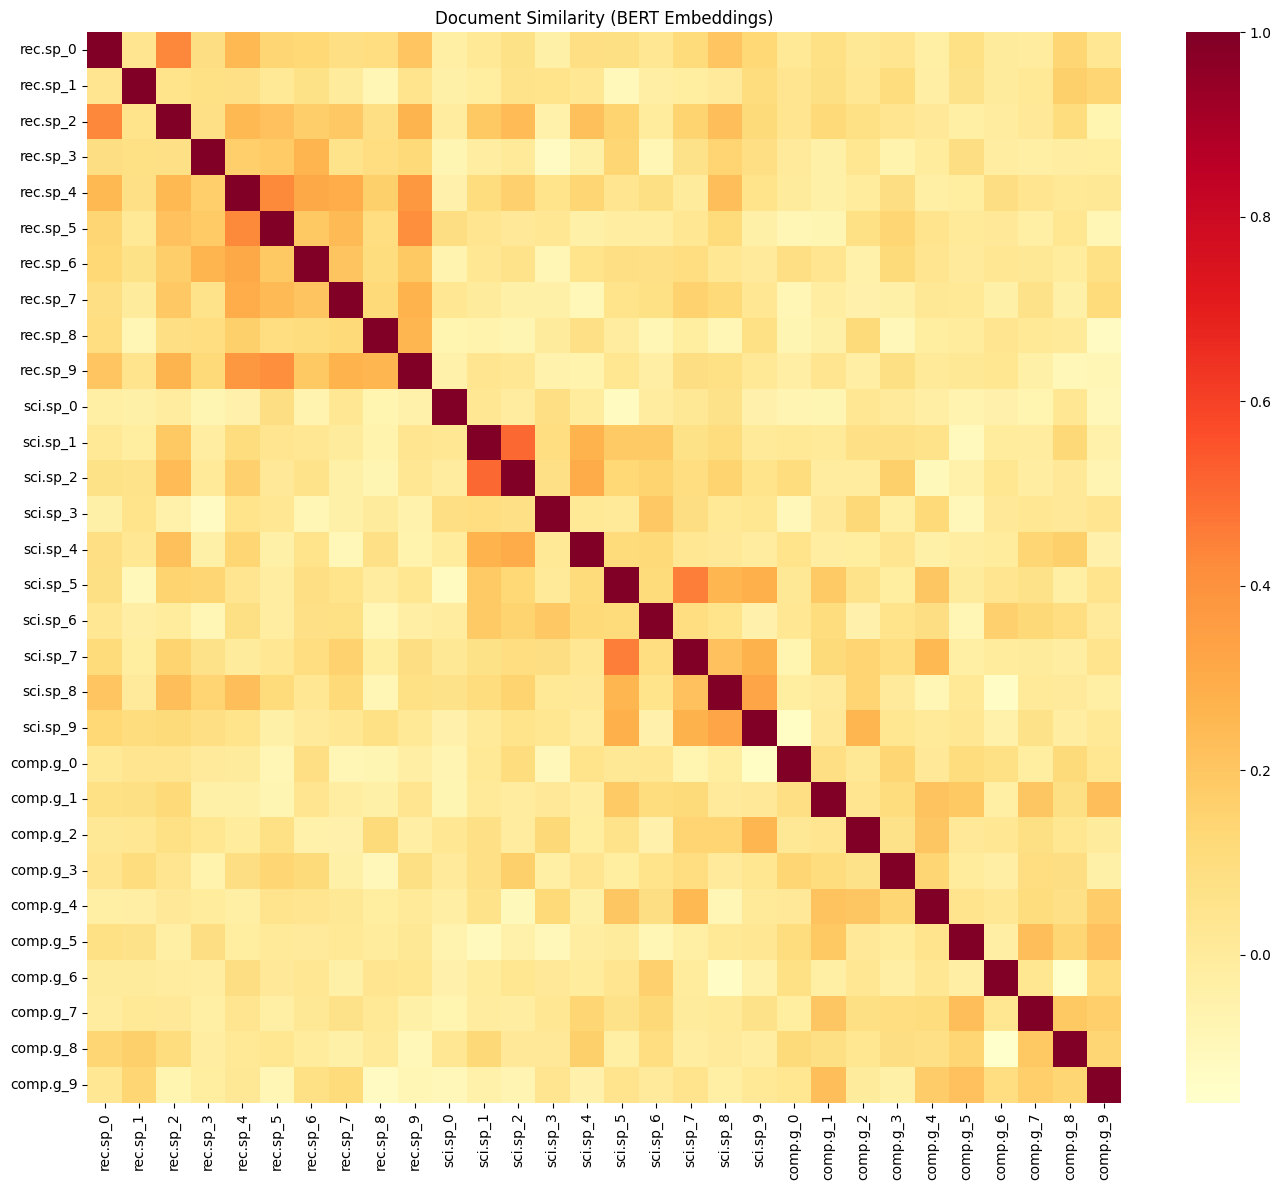

In [44]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

Better clustering with: BERT.

BERT shows better clustering because documents from the same category are grouped more clearly in the heatmap, with stronger similarity scores within each category.

Differences between methods:

BERT captures semantic meaning, while TF-IDF is based only on word frequency.
This means BERT can identify documents as similar even if they use different words but have the same meaning.

For example, two documents about space may use different vocabulary (e.g., “rocket” vs “shuttle”), and BERT will still consider them similar, while TF-IDF may not.

On the other hand, TF-IDF may consider documents similar just because they share common words, even if the overall meaning is different.

Preferred method for classification:

I would use BERT for document classification because it provides better semantic understanding of text.

BERT embeddings capture context and meaning, which leads to more accurate grouping of documents by category, especially when vocabulary varies.

TF-IDF is simpler and faster, but less powerful for understanding the meaning of text.



# Exercise C.2: Semantic Search with BERT

In [45]:
def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """

    # 1. Encode the query
    query_embedding = model.encode([query])

    # 2. Encode documents
    doc_embeddings = model.encode(documents)

    # 3. Compute cosine similarity
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # 4. Get top_k results
    top_indices = similarities.argsort()[-top_k:][::-1]

    results = [(idx, similarities[idx]) for idx in top_indices]

    return results


# -------------------------
# TEST QUERY
# -------------------------

my_query = "hockey game and team performance"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")

for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'hockey game and team performance'

Top 5 most similar documents:

  Score: 0.5070
  Category: rec.sport.hockey
  Text: Here is a review of some of the off-ice things that have
affected the AHL this year.


ST JOHN'S MAPLE LEAFS PROBLEMS
The St John's Maple Leafs sophom...

  Score: 0.4591
  Category: rec.sport.hockey
  Text: By Dave Luecking Of The Post-Dispatch Staff

At 9:11 Thursday night, the scoreboard watchers at The Arena began to cheer.
Their cheer quickly turned i...

  Score: 0.4212
  Category: rec.sport.hockey
  Text: You think that's bad?  I'm in Bowling Green, OH, and we get ABC from
Toledo.  Well, the cable co. decided to totally pre-empt the game (no tape
delay,...

  Score: 0.3402
  Category: rec.sport.hockey
  Text: 
IMO any good player should score on power plays because of the man
advantage.  Very good power play scorers tend to become overrated
because their po...

  Score: 0.3077
  Category: rec.sport.hockey
  Text: Well now that the hawks have won the divi

Relevance: Yes, the results are relevant to my query. The returned documents are clearly related to hockey, with terms such as AHL, game, player, power play, playoffs, and team-related discussions. This shows that the semantic search was able to capture the meaning of the query, not just exact keyword matching.

Category accuracy: Yes, the search correctly identified documents from the expected category. All top 5 results belong to rec.sport.hockey, which matches the query “hockey game and team performance”. This indicates that BERT embeddings are effective for retrieving semantically related documents.

Ambiguous query test: If I try a more ambiguous query such as “team strategy and performance”, the search may return documents from multiple categories, especially sports-related documents but possibly also other categories if similar words appear in different contexts. This happens because semantic search focuses on overall meaning, so broader queries can match more than one topic.

# Part D: Embedding Visualization with t-SNE

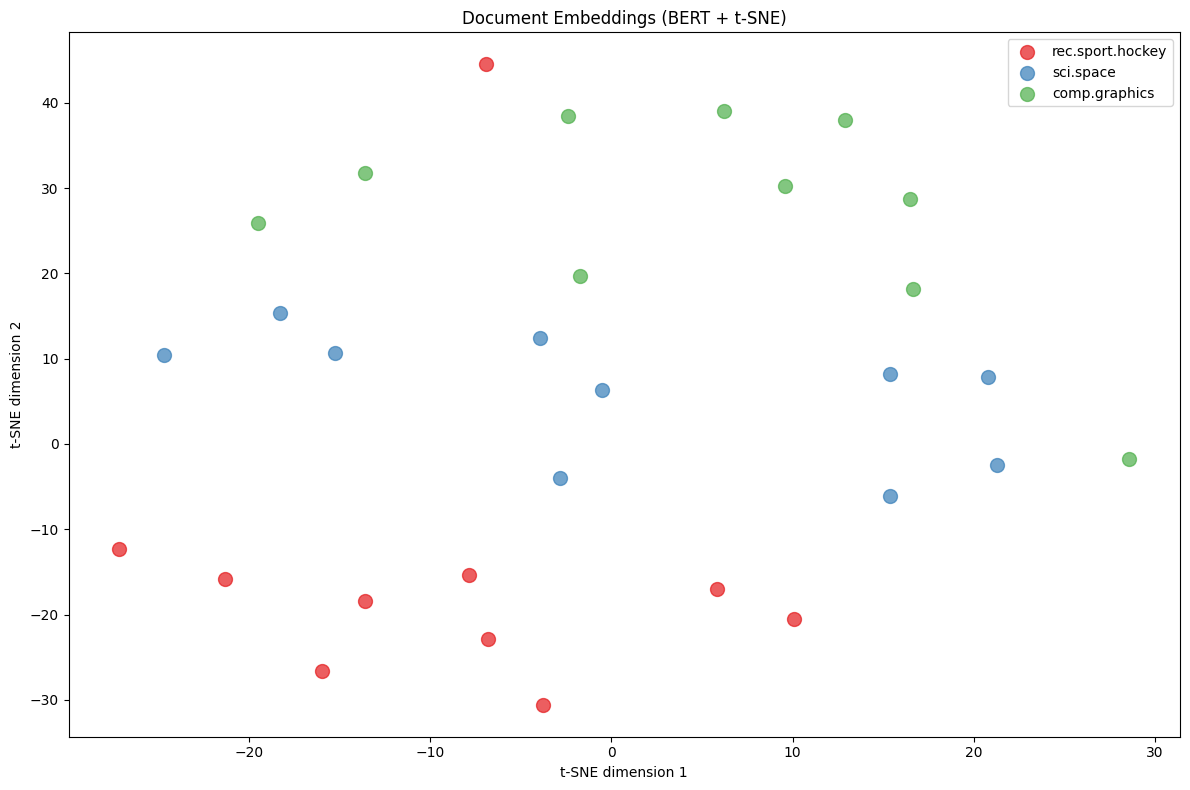

In [46]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Reduce BERT embeddings to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

# Use colors automatically
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = np.array([l == category for l in sampled_labels])

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100,
        color=color_map(i)
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

Cluster quality: The categories form fairly distinct clusters. The hockey documents (red) are clearly separated in the lower part of the plot, while the space (blue) and graphics (green) documents form their own groups. This indicates that BERT embeddings are effective at capturing semantic differences between categories.

Misplaced documents: There are a few documents that appear slightly outside their main cluster, especially some space and graphics points that are closer to each other. This could be explained by overlapping vocabulary or topics, for example technical discussions that involve both computing and scientific concepts, or documents that are less clearly focused on one category.

Most similar categories: The most similar categories appear to be sci.space and comp.graphics, as their clusters are closer to each other compared to hockey. This makes sense because both domains can involve technical and scientific vocabulary, unlike hockey which is clearly different and more isolated.

# Part E: Final Comparison and Reflection (10 min)

**1. Comparison Table**

| Method       | Strengths                                                   | Weaknesses                                         | Best Use Case                                       |
| ------------ | ----------------------------------------------------------- | -------------------------------------------------- | --------------------------------------------------- |
| **BoW**      | Simple, fast, easy to implement                             | No context, ignores word order and meaning         | Basic text classification with small datasets       |
| **TF-IDF**   | Highlights important words, better than BoW                 | Still no semantic meaning, sparse vectors          | Keyword-based search and classification             |
| **Word2Vec** | Captures semantic relationships, dense vectors              | Needs training data, limited context understanding | Learning word similarities in a specific domain     |
| **GloVe**    | Pre-trained, strong general semantic knowledge              | Not domain-specific, static embeddings             | General NLP tasks with common vocabulary            |
| **BERT**     | Deep contextual understanding, best semantic representation | Computationally expensive, slower                  | Semantic search, document classification, NLP tasks |


**2. Best Method for My Dataset**

The best method for my dataset is BERT. Based on the t-SNE visualization, BERT embeddings produced clear clusters, especially for the hockey category, which was well separated from the others. In the semantic search task, BERT correctly retrieved documents from the expected category, showing strong understanding of the query meaning. Compared to TF-IDF, BERT was able to capture semantic similarity even when different words were used. While Word2Vec and GloVe showed useful word relationships, they were less effective at representing full documents. Overall, BERT provided the most accurate and meaningful representation of my dataset.

**3. My Recommendation for a Real System**

For a real document classification system, I would use BERT embeddings. BERT captures the context and meaning of text, which leads to better classification performance, especially when documents use varied vocabulary. Even though it is more computationally expensive, the improvement in accuracy and semantic understanding makes it the best choice. For production, I might use a lighter version like MiniLM to balance performance and speed.